In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
link = r"https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
df1 = pd.read_excel(link, sheet_name='Year 2009-2010')
df2 = pd.read_excel(link, sheet_name='Year 2010-2011')

In [3]:
df1.shape, df2.shape

((525461, 8), (541910, 8))

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [5]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df = pd.concat([df1, df2], ignore_index=True)
df.shape

(1067371, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [8]:
df.dropna(subset='Customer ID', inplace=True)
df.shape

(824364, 8)

In [9]:
df.iloc[100:200]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
100,489442,22271,FELTCRAFT DOLL ROSIE,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
101,489442,22272,FELTCRAFT DOLL MARIA,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
102,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
103,489442,21582,KINGS CHOICE SMALL TUBE MATCHES,20,2009-12-01 09:46:00,1.65,13635.0,United Kingdom
104,489442,21586,KINGS CHOICE GIANT TUBE MATCHES,12,2009-12-01 09:46:00,2.55,13635.0,United Kingdom
...,...,...,...,...,...,...,...,...
195,489450,22090,PAPER BUNTING RETRO SPOTS,12,2009-12-01 10:36:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
197,C489459,90200D,PINK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom
198,C489459,90200B,BLACK SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [10]:
df = df[(~df['Invoice'].astype('str').str.startswith('C')) | (df['Quantity'].gt(0))]

In [11]:
df['Revenue'] = df['Quantity'] * df['Price']

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
 8   Revenue      805620 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 61.5+ MB


In [13]:
df['month'] = df['InvoiceDate'].dt.to_period('M')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [14]:
month_rev = df.groupby(by='month')['Revenue'].sum().sort_index()
month_rev

month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Freq: M, Name: Revenue, dtype: float64

In [15]:
month_rev.index, month_rev.values

(PeriodIndex(['2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05',
              '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11',
              '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05',
              '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11',
              '2011-12'],
             dtype='period[M]', name='month'),
 array([ 686654.16 ,  557319.062,  506371.066,  699608.991,  594609.192,
         599985.79 ,  639066.58 ,  591636.74 ,  604242.65 ,  831615.001,
        1036680.   , 1172336.042,  884591.89 ,  569445.04 ,  447137.35 ,
         595500.76 ,  469200.361,  678594.56 ,  661213.69 ,  600091.011,
         645343.9  ,  952838.382, 1039318.79 , 1161817.38 ,  518210.79 ]))

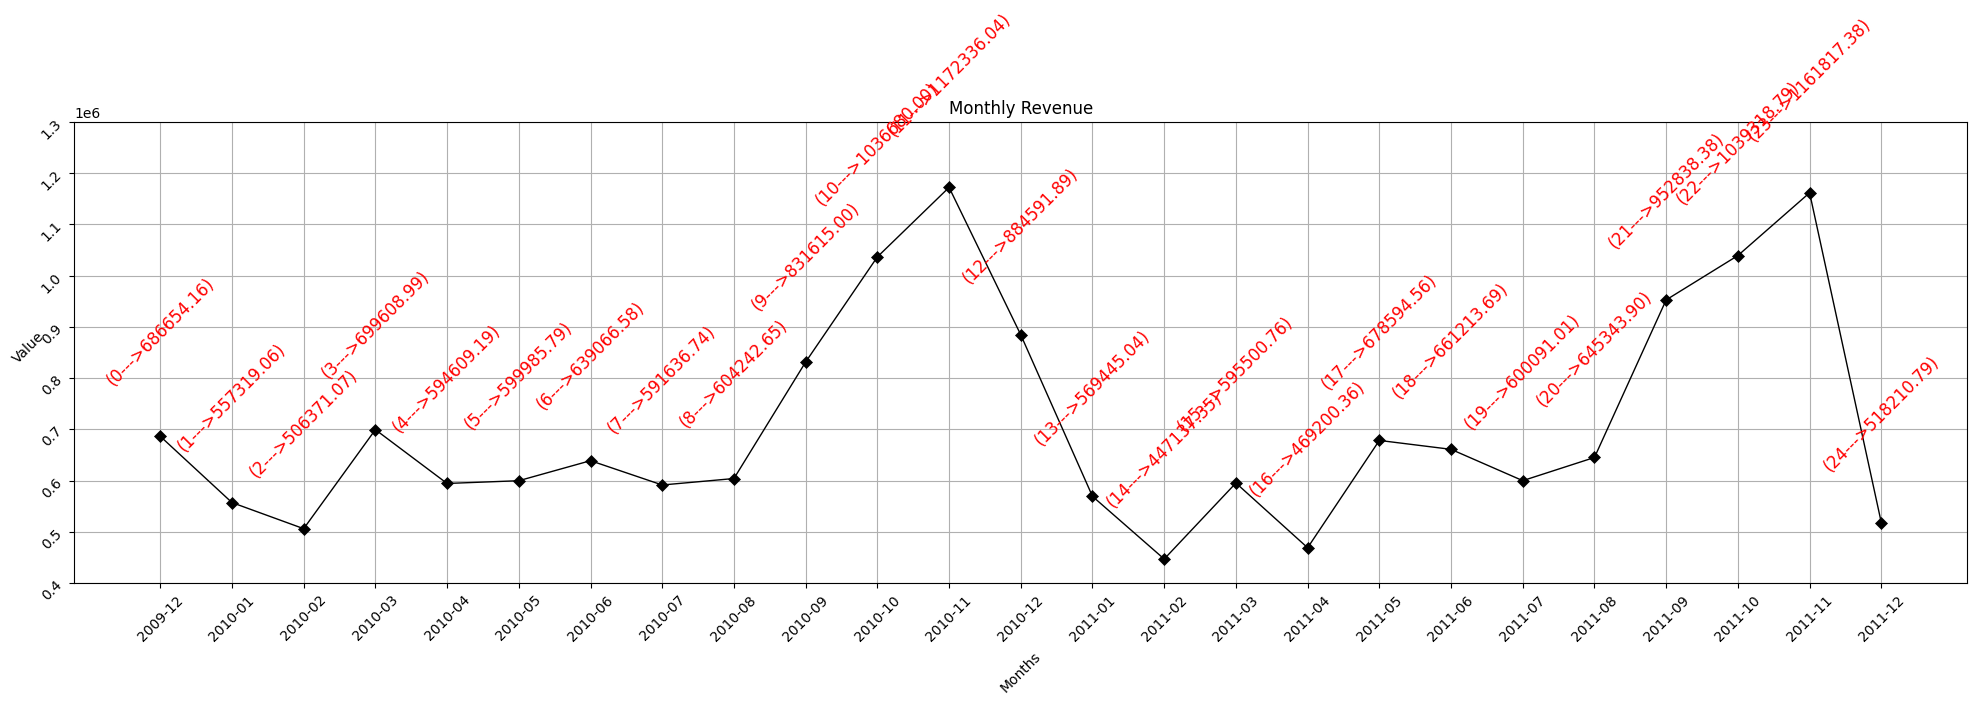

In [16]:
plt.figure(figsize=(20,6))
plt.title(label='Monthly Revenue')
plt.xlabel(xlabel='Months', rotation=45)
plt.ylabel(ylabel='Value', rotation=45)

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.style.use('classic')

for i, val in enumerate(month_rev.values):
    plt.text(str(month_rev.index[i]), val+100000, f'({i}--->{val:.2f})', ha='center',fontsize=12, color='r', rotation=45)

plt.plot(month_rev.index.astype('str'), month_rev.values, marker='D', color='black')
plt.show()

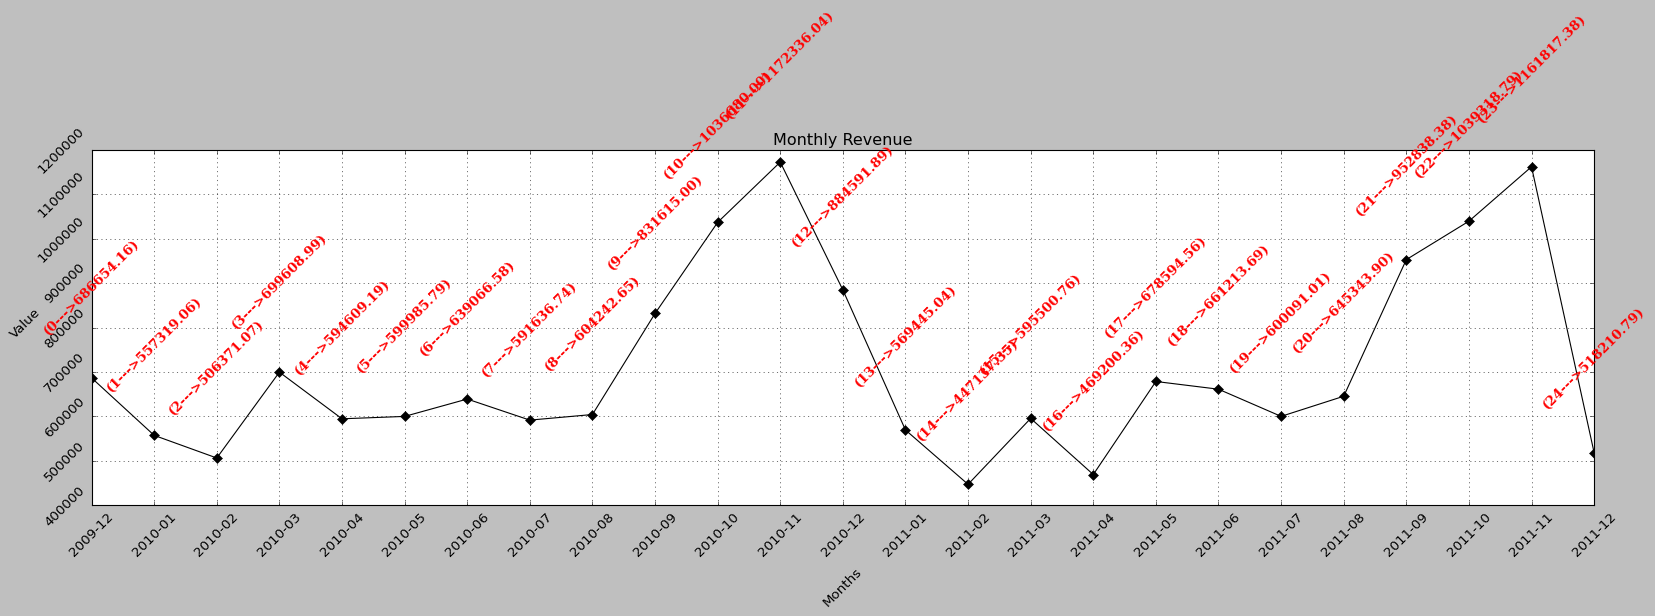

In [17]:
font = {
    'family' : 'serif',
    'color' : 'r',
    'weight' : 'bold',
    'size' : 12
}

plt.figure(figsize=(20,6))
plt.title(label='Monthly Revenue')
plt.xlabel(xlabel='Months', rotation=45)
plt.ylabel(ylabel='Value', rotation=45)

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.style.use('classic')

for i, val in enumerate(month_rev.values):
    plt.text(str(month_rev.index[i]), val+100000, f'({i}--->{val:.2f})', ha='center',fontdict=font, rotation=45)

plt.plot(month_rev.index.astype('str'), month_rev.values, marker='D', color='black')
plt.show()

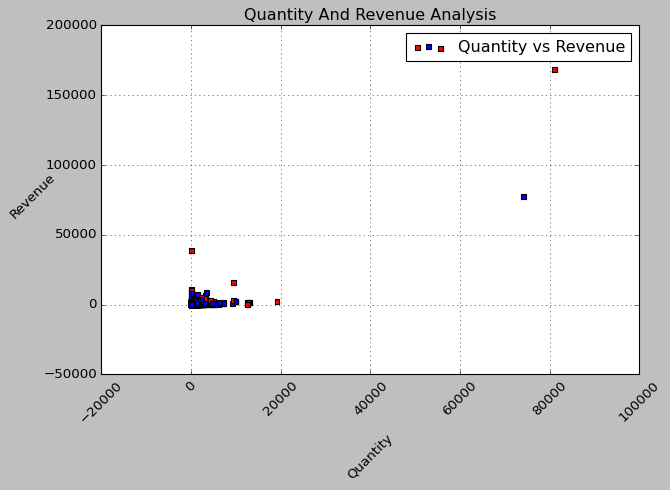

In [18]:
colors = ['red' if i % 2 == 0 else 'blue' for i in range(len(df))]

plt.Figure(figsize=(30, 10))
plt.title('Quantity And Revenue Analysis')
plt.xlabel(xlabel='Quantity', rotation=45)
plt.ylabel(ylabel='Revenue', rotation=45)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.scatter(df['Quantity'], df['Revenue'], marker='s', c=colors, label='Quantity vs Revenue')
plt.legend()
plt.show()

In [19]:
mont_rev = df.groupby('month')['Revenue'].sum().sort_index()
mont_qt = df.groupby('month')['Quantity'].sum().sort_index()

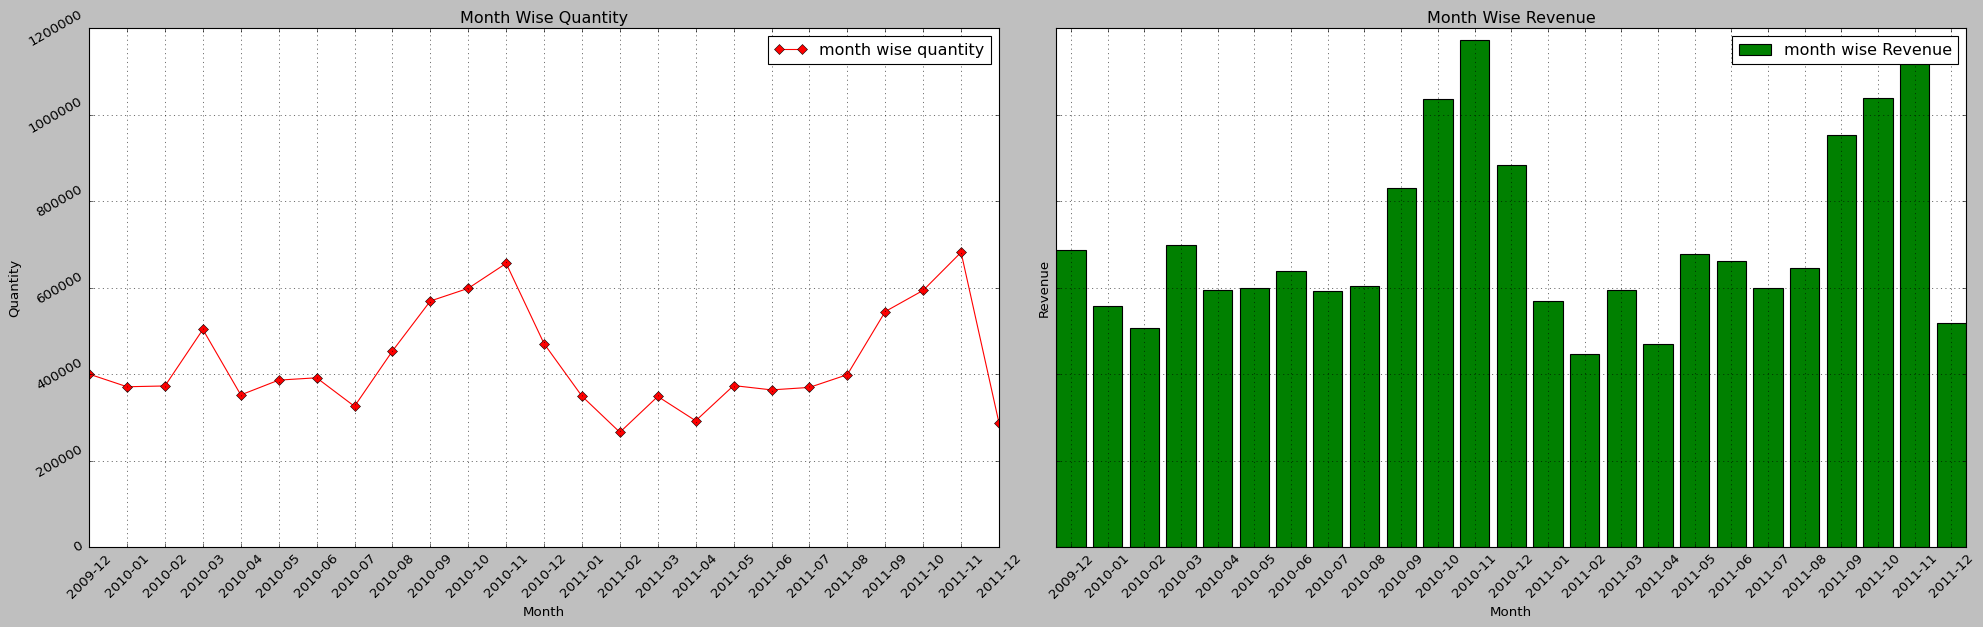

In [20]:
fig, (qts_1, qts_2) = plt.subplots(figsize=(25,8), nrows=1, ncols=2, sharey=True)

qts_1.plot(mont_qt.index.astype('str'), mont_qt.values, color='r', marker='D', label='month wise quantity')
qts_1.set_title('Month Wise Quantity')
qts_1.set_xlabel("Month")
qts_1.set_ylabel("Quantity")
qts_1.tick_params(rotation=45, axis='x')
qts_1.tick_params(axis='y', rotation=30)
qts_1.legend()
qts_1.grid(True)

qts_2.bar(mont_rev.index.astype('str'), mont_rev.values, color='g', label='month wise Revenue')
qts_2.set_title('Month Wise Revenue')
qts_2.set_xlabel("Month")
qts_2.set_ylabel("Revenue")
qts_2.tick_params(axis='x', rotation=45)
qts_2.legend()
qts_2.grid(True)

plt.tight_layout()
plt.show()

plt.savefig("monthly_revenue_plot.png", dpi=300)
plt.close()


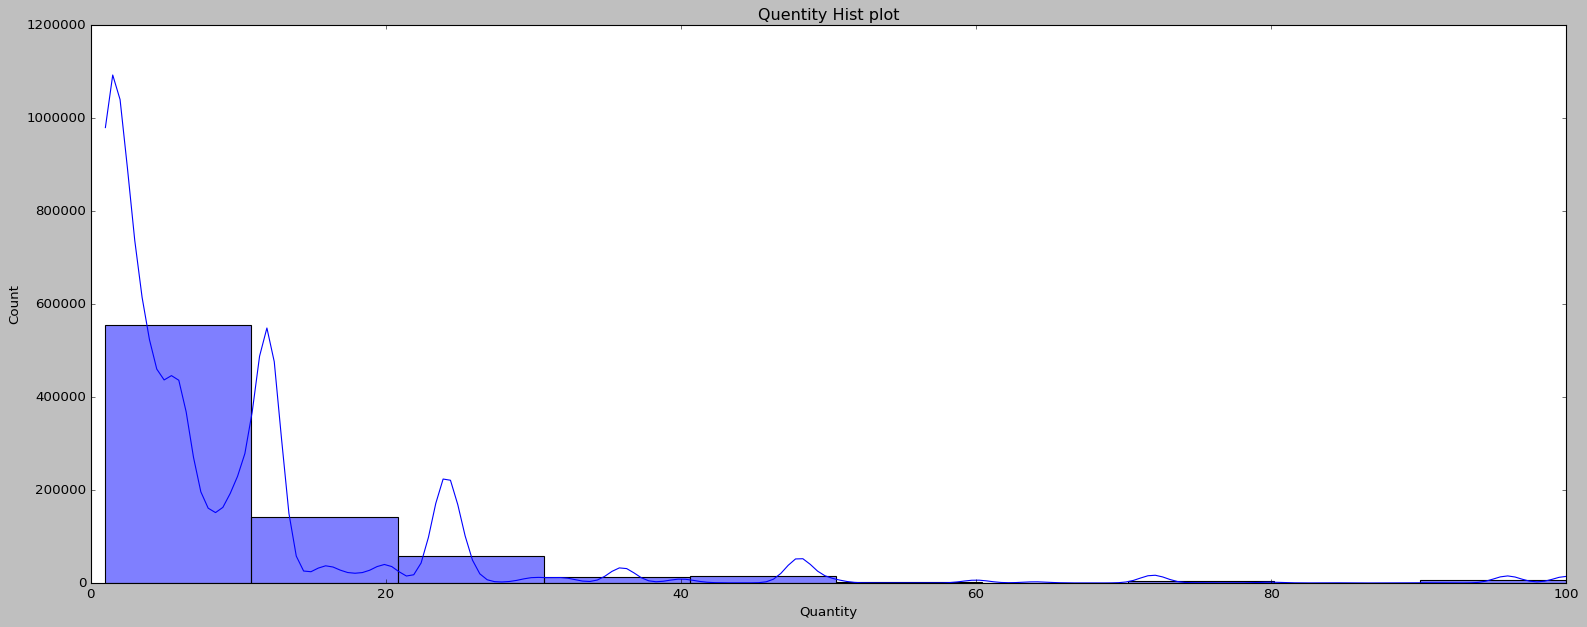

In [40]:
trans_qunt = df[(df['Quantity'] > 0) & (df['Quantity'] <= 100)]

plt.figure(figsize=(20,8))
sns.histplot(trans_qunt, bins=10, kde=True, x=trans_qunt['Quantity'], fill=True)
plt.title('Quentity Hist plot')
plt.tight_layout()
plt.show()

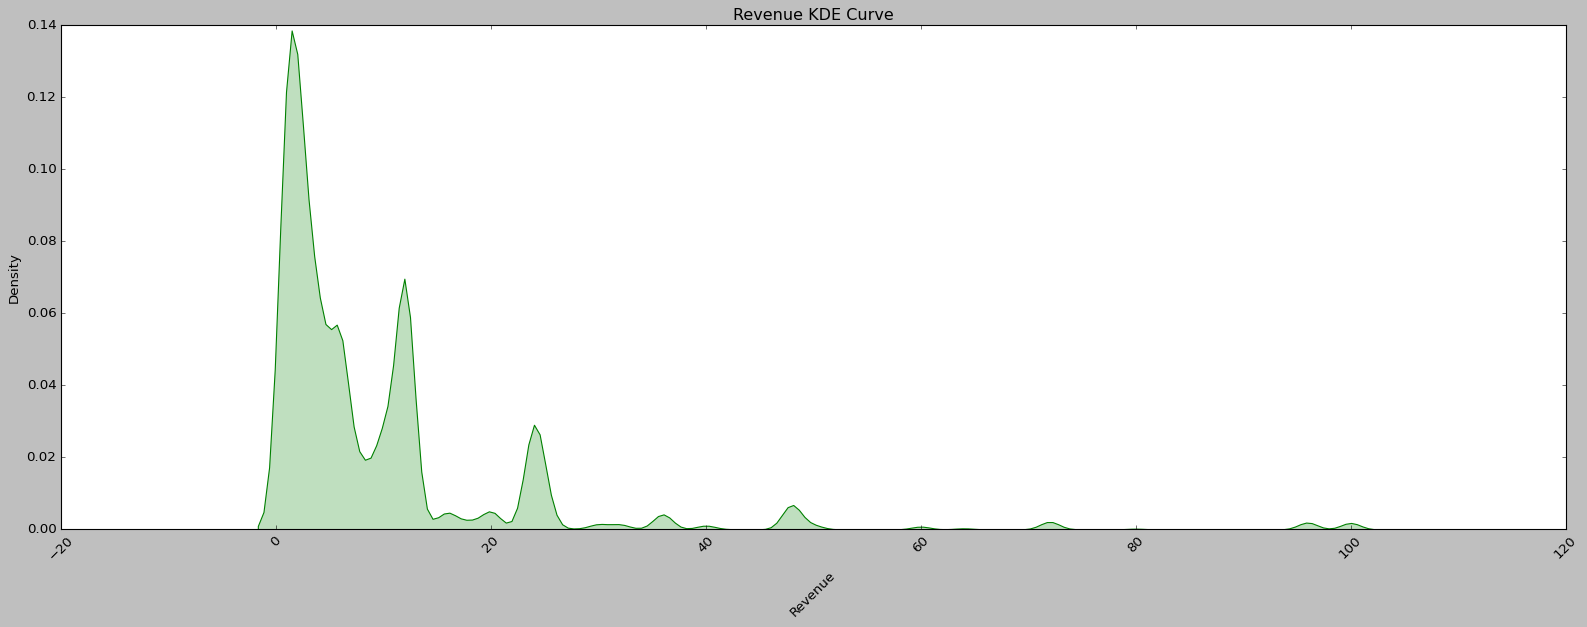

In [45]:
# sns.kdeplot() — KDE (smooth version of histogram)
plt.figure(figsize=(20, 8))
sns.kdeplot(trans_qunt['Quantity'], fill=True, color='green')
plt.title('Revenue KDE Curve')
plt.xlabel('Revenue', rotation=45)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
df_revenue_sample = df[(df['Revenue'] > 1000) & (df['Revenue'] < 2000)]
df_revenue_sample

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,month
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,1160.00,2009-12
3290,489675,15056BL,EDWARDIAN PARASOL BLACK,240,2009-12-02 09:47:00,4.60,13777.0,United Kingdom,1104.00,2009-12
4793,489831,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-02 13:58:00,2.10,12435.0,Denmark,1008.00,2009-12
6443,489889,85123A,WHITE HANGING HEART T-LIGHT HOLDER,480,2009-12-02 16:52:00,2.55,14646.0,Netherlands,1224.00,2009-12
7007,490010,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-03 12:15:00,2.10,15061.0,United Kingdom,1008.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
1059196,581105,22727,ALARM CLOCK BAKELIKE RED,620,2011-12-07 12:14:00,2.99,16000.0,United Kingdom,1853.80,2011-12
1059200,581105,23552,BICYCLE PUNCTURE REPAIR KIT,620,2011-12-07 12:14:00,1.86,16000.0,United Kingdom,1153.20,2011-12
1065521,581457,22189,CREAM HEART CARD HOLDER,324,2011-12-08 18:43:00,3.39,18102.0,United Kingdom,1098.36,2011-12
1065524,581457,23553,LANDMARK FRAME CAMDEN TOWN,120,2011-12-08 18:43:00,10.95,18102.0,United Kingdom,1314.00,2011-12


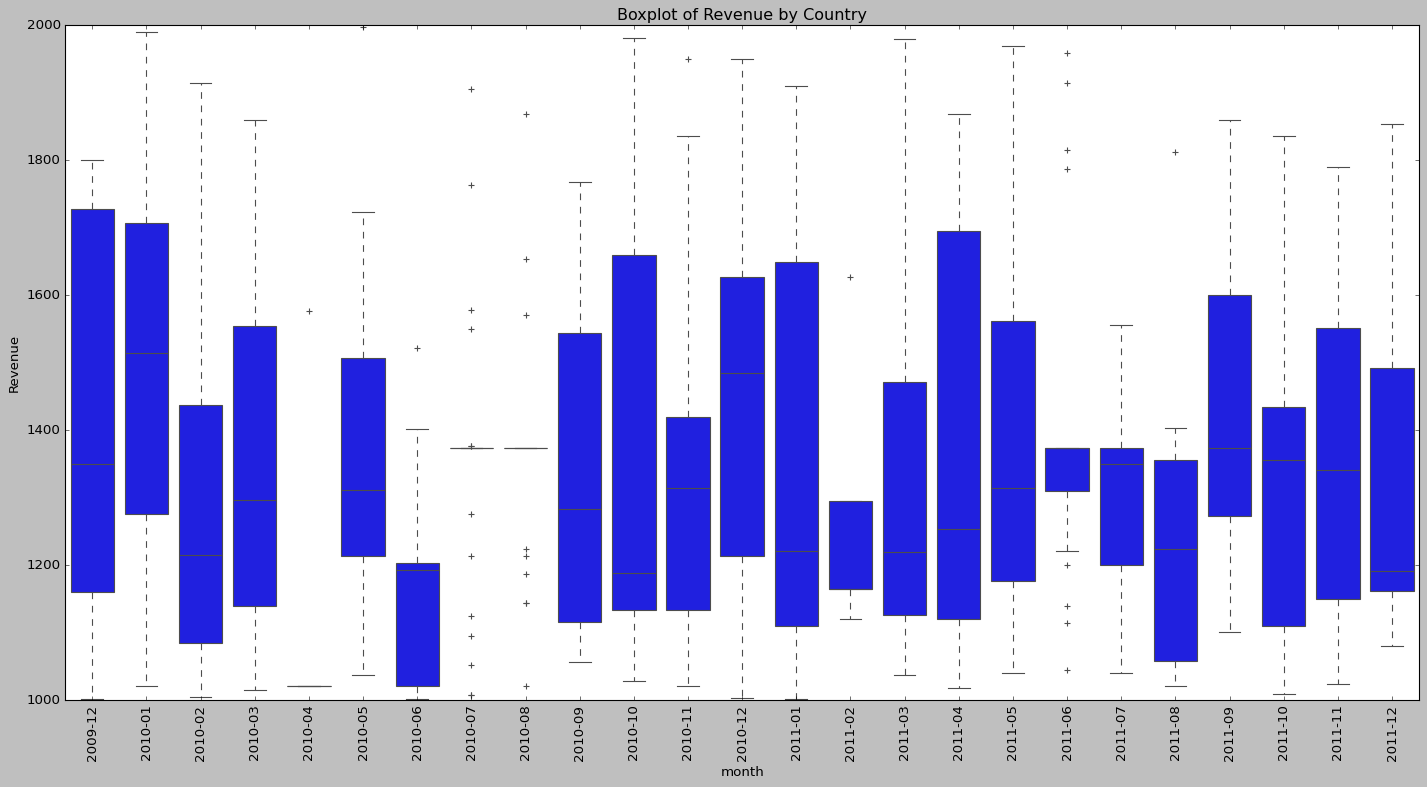

In [49]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df_revenue_sample, x='month', y='Revenue')
plt.xticks(rotation=90)
plt.title('Boxplot of Revenue by Country')
plt.tight_layout()
plt.show()